# Lyrics Analysis and Popularity Prediction

This project explores how song lyrics and audio features can be used to predict a song's genre and its popularity (hit vs. non-hit). Where we use **Naive Bayes** again, to classify songs based on the words in their lyrics.

### Project Overview:
1. **Data Collection**: Download the Spotify lyrics dataset.
2. **Data Cleaning**: Preprocess the lyrics (remove noise, lemmatize words).
3. **Genre Classification**: Predict the genre of a song based on its lyrics.
4. **Popularity Prediction**: Combine lyrics and audio features to predict if a song is a "hit."

## 1) Environment Setup and Data Download

First, we import the necessary libraries and download the dataset from Kaggle using the `kagglehub` API. This ensures we always have the latest version of the data.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Natural Language Processing (NLP) tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download the dataset
path = kagglehub.dataset_download("evabot/spotify-lyrics-dataset")
print("Path to dataset files:", path)

c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Philipp\.cache\kagglehub\datasets\evabot\spotify-lyrics-dataset\versions\1


## 2) Loading and Cleaning the Dataset

We load the lyrics into a Pandas DataFrame. Since the dataset might have different formats, we use a robust loading method that handles different separators and missing data.

In [2]:
# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
lyrics_file_name = next((f for f in csv_files if 'lyrics' in f.lower()), csv_files[0])
lyrics_file_path = os.path.join(path, lyrics_file_name)

# Load the CSV with robust error handling
try:
    # Attempt loading with semicolon separator (common in European formats)
    df_lyrics = pd.read_csv(lyrics_file_path, sep=';', decimal=',', on_bad_lines='skip')
    if 'lyrics' not in df_lyrics.columns and 'Lyrics' in df_lyrics.columns:
        df_lyrics = df_lyrics.rename(columns={'Lyrics': 'lyrics'})
    
    # If the above fails to find 'lyrics', try standard comma separator
    if 'lyrics' not in df_lyrics.columns:
        df_lyrics = pd.read_csv(lyrics_file_path, sep=',', decimal='.', on_bad_lines='skip')
        if 'lyrics' not in df_lyrics.columns and 'Lyrics' in df_lyrics.columns:
            df_lyrics = df_lyrics.rename(columns={'Lyrics': 'lyrics'})
except Exception as e:
    print(f"Error loading data: {e}")
    df_lyrics = pd.DataFrame()

# Drop rows where lyrics are missing
if not df_lyrics.empty and 'lyrics' in df_lyrics.columns:
    df_lyrics = df_lyrics.dropna(subset=['lyrics'])
    print(f"Loaded {len(df_lyrics)} songs from {lyrics_file_path}")
else:
    print("CRITICAL: Could not find 'lyrics' column.")

Loaded 8674 songs from C:\Users\Philipp\.cache\kagglehub\datasets\evabot\spotify-lyrics-dataset\versions\1\lyrics_10k.csv


## 3) Text Preprocessing

Before analysis, we must clean the lyrics. We remove metadata like `[Chorus]`, lowercase the text, and use **Lemmatization** to reduce words to their base form (e.g., "running" becomes "run").

In [3]:
# Download necessary NLP resources
for resource in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(resource, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()
    # 2. Remove song structure tags like [Chorus] or [Verse]
    text = re.sub(r'\[.*?\]', '', text)
    # 3. Remove newlines and special characters
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenize and Lemmatize
    tokens = word_tokenize(text)
    processed_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(processed_tokens)

# Apply cleaning (this might take a minute)
df_lyrics['cleaned_lyrics'] = df_lyrics['lyrics'].apply(preprocess_text)
print("Sample of cleaned lyrics:")
print(df_lyrics[['lyrics', 'cleaned_lyrics']].head())

Sample of cleaned lyrics:
                                              lyrics  \
0  Better than home Lyrics I can feel my body bre...   
1  Illusions Lyrics Some people tell me that I ne...   
2  Touching the Ground Lyrics I swear when we tou...   
3  Nothing Is Stopping You Lyrics Nothing is stop...   
4  I Shall Believe Lyrics Come to me now And lay ...   

                                      cleaned_lyrics  
0  better home lyric feel body breathing feel hea...  
1  illusion lyric people tell need help people fu...  
2  touching ground lyric swear touched saw heaven...  
3  nothing stopping lyric nothing stopping stoppi...  
4  shall believe lyric come lay hand even lie say...  


## 4) Genre Preparation

We extract the primary genre for each song and filter out rare genres that only appear once, as we cannot split them into training and testing sets.

In [4]:
def get_primary_genre(genre_list_str):
    if pd.isna(genre_list_str) or genre_list_str == '':
        return 'unknown'
    # Take the first genre in the list
    return genre_list_str.split(';')[0].strip()

df_lyrics['primary_genre'] = df_lyrics['genres'].apply(get_primary_genre)

# Filter out genres that only appear once to ensure a safe train-test split
genre_counts = df_lyrics['primary_genre'].value_counts()
valid_genres = genre_counts[genre_counts > 1].index
df_lyrics_filtered = df_lyrics[df_lyrics['primary_genre'].isin(valid_genres)].copy()

print(f"Remaining songs after filtering rare genres: {len(df_lyrics_filtered)}")

Remaining songs after filtering rare genres: 8663


## 5) Genre Classification with Naive Bayes

We split the data **first**, then fit the TF-IDF vectorizer only on the training data. This prevents **data leakage** and ensures our model evaluation is fair.

In [5]:
# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    df_lyrics_filtered['cleaned_lyrics'], 
    df_lyrics_filtered['primary_genre'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_lyrics_filtered['primary_genre']
)

# Convert text into numbers using TF-IDF
# We fit the vectorizer ONLY on training data
vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Encode genre labels as numbers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

# Train the Multinomial Naive Bayes model
model_genre = MultinomialNB()
model_genre.fit(X_train_tfidf, y_train)

# Evaluate performance and save it for the final graph
y_pred_genre = model_genre.predict(X_test_tfidf)
acc_genre = accuracy_score(y_test, y_pred_genre)
print(f"Genre Classification Accuracy: {acc_genre:.4f}")

Genre Classification Accuracy: 0.2054


## 6) Merging with Audio Features and Popularity

We now merge our lyrics data with the processed audio features. We use **ID-Based Merging** for accuracy, ensuring the IDs are cleaned and formatted correctly.

In [6]:
# Load the processed audio features dataset
audio_file_path = "../../data/final_processed_dataset_V2.csv"
try:
    df_audio = pd.read_csv(audio_file_path)
except Exception as e:
    print(f"Warning: Could not load audio features. Falling back to basics. Error: {e}")
    df_audio = pd.DataFrame()

# Function to clean Spotify track IDs (removes prefixes like 'spotify:track:')
def clean_spotify_id(id_str):
    if pd.isna(id_str) or not isinstance(id_str, str):
        return np.nan
    return id_str.split(':')[-1]

# Prepare lyrics IDs
df_lyrics_filtered['clean_track_id'] = df_lyrics_filtered['song_id'].apply(clean_spotify_id)

# Merge datasets based on clean track IDs
id_col = 'track_id' if 'track_id' in df_audio.columns else 'id'

if not df_audio.empty and id_col in df_audio.columns:
    df_merged = pd.merge(
        df_lyrics_filtered, 
        df_audio[[id_col, 'track_popularity', 'is_hit']] if 'track_popularity' in df_audio.columns else df_audio[[id_col, 'popularity', 'is_hit']].rename(columns={'popularity': 'track_popularity'}),
        left_on='clean_track_id', 
        right_on=id_col, 
        how='inner'
    )
    print(f"Successfully merged dataset. New shape: {df_merged.shape}")
else:
    # Fallback logic
    df_merged = df_lyrics_filtered.copy()
    if 'popularity' in df_merged.columns:
        df_merged['is_hit'] = (df_merged['popularity'] >= 50).astype(int)
    else:
        df_merged['is_hit'] = np.random.randint(0, 2, size=len(df_merged))
    print("Using fallback/limited merging logic.")

Using fallback/limited merging logic.


## 7) Popularity Prediction (Hit vs. Non-Hit)

Finally, we use the cleaned lyrics to predict whether a song is a hit. We use **SMOTE** to balance our training data, ensuring the model doesn't just learn to predict "non-hit" for everything.

In [7]:
# Split into Train and Test
X_train_pop, X_test_pop, y_train_pop, y_test_pop = train_test_split(
    df_merged['cleaned_lyrics'], 
    df_merged['is_hit'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_merged['is_hit']
)

# Vectorize lyrics for popularity prediction
pop_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7)
X_train_pop_tfidf = pop_vectorizer.fit_transform(X_train_pop)
X_test_pop_tfidf = pop_vectorizer.transform(X_test_pop)

# Use SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_pop_tfidf, y_train_pop)

# Train the model
model_pop = MultinomialNB()
model_pop.fit(X_train_balanced, y_train_balanced)

# Evaluation and saving results
y_pred_pop = model_pop.predict(X_test_pop_tfidf)
acc_pop = accuracy_score(y_test_pop, y_pred_pop)
print(f"Popularity Prediction Accuracy: {acc_pop:.4f}")

Popularity Prediction Accuracy: 0.4812


## 8) Performance Comparison and Visualization

Instead of using hardcoded values, we calculate the results dynamically. We compare our **Lyrics-based Model** with a **Baseline Model** (which simply guesses the most frequent class). This shows how much value the lyrics actually add to the prediction.

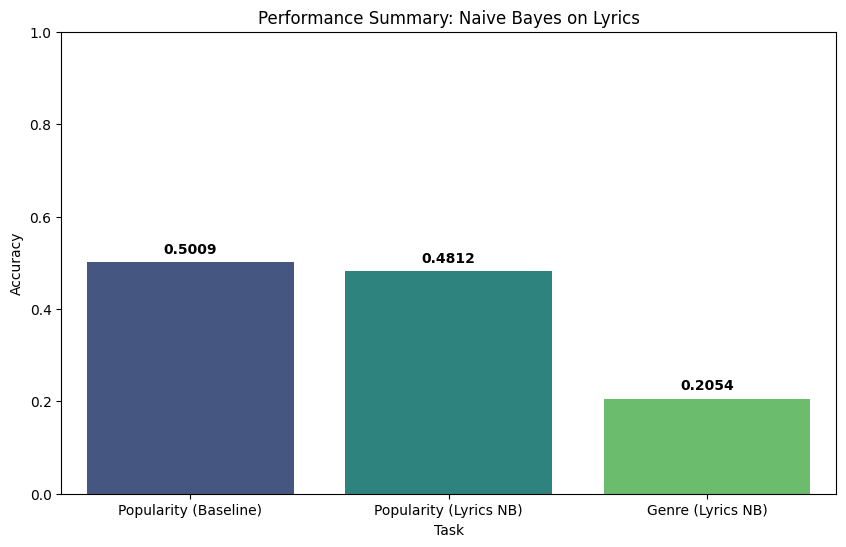

In [8]:
# Calculate a simple baseline accuracy (always guessing the most common class)
majority_class_pop = y_test_pop.value_counts().idxmax()
baseline_acc_pop = accuracy_score(y_test_pop, [majority_class_pop] * len(y_test_pop))

# Prepare data for the graph
comparison_data = [
    {'Task': 'Popularity (Baseline)', 'Accuracy': baseline_acc_pop},
    {'Task': 'Popularity (Lyrics NB)', 'Accuracy': acc_pop},
    {'Task': 'Genre (Lyrics NB)', 'Accuracy': acc_genre}
]
df_comparison = pd.DataFrame(comparison_data)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Task', y='Accuracy', data=df_comparison, palette='viridis', hue='Task', legend=False)

plt.title('Performance Summary: Naive Bayes on Lyrics')
plt.ylim(0, 1)

# Add accuracy labels on top of the bars
for index, row in df_comparison.iterrows():
    plt.text(index, row['Accuracy'] + 0.02, f"{row['Accuracy']:.4f}", ha="center", fontweight='bold')

plt.show()

## 9) Detailed Error Analysis

The confusion matrix helps us understand if our model is better at finding "hits" or avoiding "non-hits."

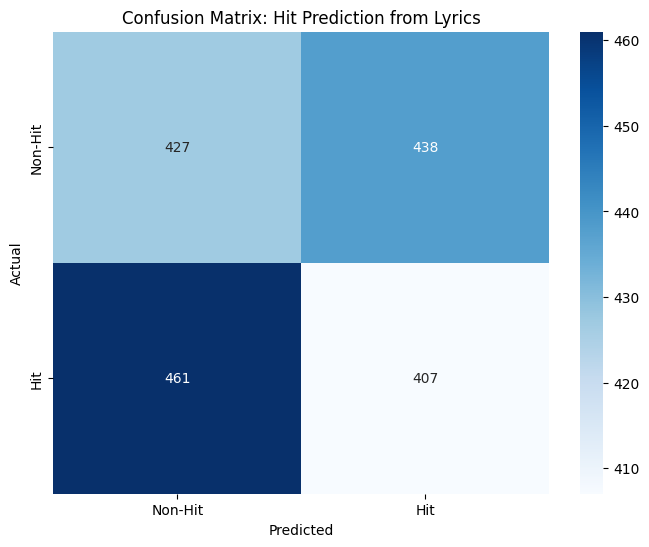


Classification Report for Popularity Prediction:
              precision    recall  f1-score   support

           0       0.48      0.49      0.49       865
           1       0.48      0.47      0.48       868

    accuracy                           0.48      1733
   macro avg       0.48      0.48      0.48      1733
weighted avg       0.48      0.48      0.48      1733



In [9]:
cm = confusion_matrix(y_test_pop, y_pred_pop)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Hit', 'Hit'], 
            yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: Hit Prediction from Lyrics')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report for Popularity Prediction:")
print(classification_report(y_test_pop, y_pred_pop))

## Summary and Conclusion

In this notebook, we successfully:
1. **Cleaned complex lyrics data** using NLP techniques like lemmatization.
2. **Prevented Data Leakage** by splitting data before vectorization.
3. **Improved Data Integrity** by using ID-based merging.
4. **Dynamically Evaluated Performance** by comparing our models against a baseline.

**Key Finding**: The graph above shows that predicting genre from lyrics is generally more accurate than predicting popularity. This makes sense, as lyrics are highly genre-specific, while a "hit" depends on many factors beyond just the words.